In [1]:
# !unzip -o -q ./data/deepseek-new.zip -d ./data/

## Dependencies

In [2]:
import pandas as pd
import numpy as np

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.cli import tqdm
from tqdm import trange

from icecream import ic

import os

## Data Preparing

In [3]:
df_labled = pd.read_csv('./data/train.csv')
df_test = pd.read_csv('./data/test.csv')
df_labled.head()

,id,label
0,44263a6b,Scyther
1,9b6344f2,Butterfree
2,c89ffbde,Rhydon
3,95bbd7ff,Koffing
4,c3e8a9e1,Dewgong


In [4]:
df_test.head()

,id
0,9553b359
1,c6bcf2c2
2,5493d25f
3,f17f13b5
4,bb4e5386


### EDA

In [5]:
df_labled.shape

(5243, 2)

In [6]:
df_labled['label'].nunique()

150

<Axes: xlabel='label', ylabel='Count'>

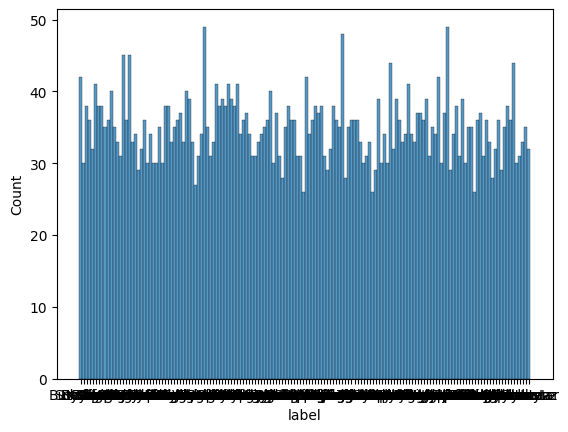

In [7]:
sns.histplot(df_labled, x='label')

In [8]:
df_train, df_val = train_test_split(df_labled, test_size=0.3, stratify=df_labled['label'], shuffle=True, random_state=42)
df_train.shape, df_val.shape

((3670, 2), (1573, 2))

<Axes: xlabel='label', ylabel='count'>

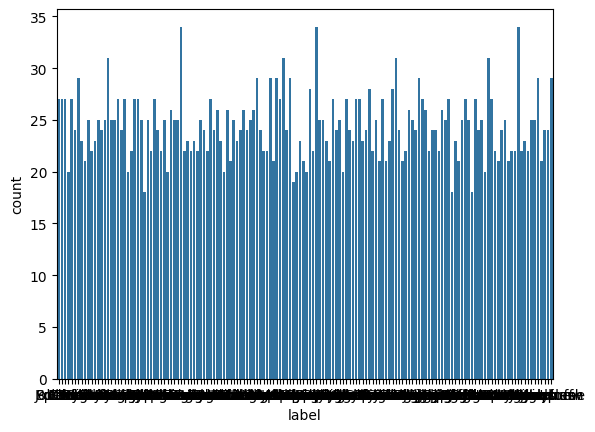

In [9]:
sns.countplot(data=df_train, x='label')

<Axes: xlabel='label', ylabel='count'>

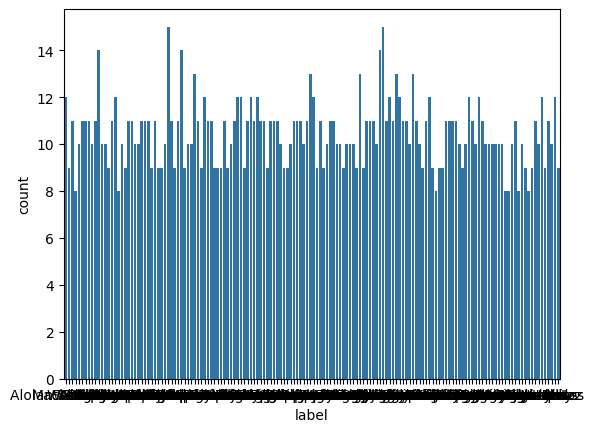

In [10]:
sns.countplot(data=df_val, x='label')

In [11]:
label_encoder = LabelEncoder()
label_encoder.fit(df_labled['label'])

LabelEncoder()

In [12]:
label_encoder.inverse_transform([0])

array(['Abra'], dtype=object)

In [13]:
label_encoder.transform(['Abra'])

array([0])

### Custom Dataset & Transforms

In [14]:
class PockemonDataset(Dataset):
    def __init__(self, df: pd.DataFrame, img_path: str, transform: transforms.Compose = None, is_test = False):
        super().__init__()

        self.df = df
        self.img_path = img_path
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return self.df.shape[0]

    def __getitem__(self, index):
        id = self.df.iloc[index]['id']
        label = 0
        if not self.is_test:
            label = self.df.iloc[index]['label']
            label = label_encoder.transform([label])[0]

        img_path = os.path.join(self.img_path, f"{id}.jpg")
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return (img, label)

In [15]:
IN_SHAPE = (128, 128)

train_transforms = transforms.Compose([
    transforms.Resize(IN_SHAPE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    transforms.RandomRotation(20),
    transforms.GaussianBlur(3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize(IN_SHAPE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

### DataLoaders

In [16]:
train_dataset = PockemonDataset(df_train, "./data/train", train_transforms)
val_dataset = PockemonDataset(df_val, "./data/train", test_transforms)
test_dataset = PockemonDataset(df_test, "./data/test", test_transforms, is_test=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.4896734].


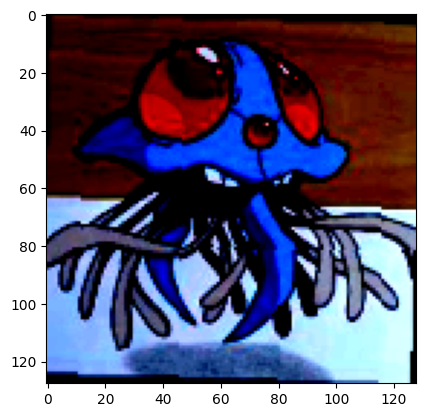

In [17]:
img_idx = np.random.randint(0, len(train_dataset))
img = train_dataset[img_idx][0].numpy()
img = np.transpose(img, (1, 2, 0))

plt.imshow(img)

In [18]:
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=8, persistent_workers=True)
val_dataloader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=8, persistent_workers=True)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

## Training

### Train Loop

In [19]:
def train_loop(
        model: nn.Module,
        train_loader: DataLoader,
        val_loader: DataLoader,
        optimizer: torch.optim.AdamW,
        criterion = nn.CrossEntropyLoss(),
        num_epoches = 100,
        model_name = "best_model.pth"
    ):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    train_losses = []
    val_losses = []
    val_metrics = []

    for epoch in trange(num_epoches):
        model.train()
        cur_train_loss = 0.
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)

            optimizer.zero_grad()
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            cur_train_loss += loss.item()
        
        train_losses.append(cur_train_loss / len(train_loader))
        
        model.eval()
        cur_val_loss = 0.
        cur_preds = []
        val_labels = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)

                loss = criterion(y_pred, y_batch)
                cur_val_loss += loss.item()

                y_pred = y_pred.detach().cpu().numpy()
                y_pred = np.argmax(y_pred, axis=1)
                y_batch = y_batch.cpu().numpy()

                val_labels.extend(y_batch)
                cur_preds.extend(y_pred)

        val_losses.append(cur_val_loss / len(val_loader))
        cur_metric = f1_score(val_labels, cur_preds, average='macro')
        if len(val_metrics) < 2 or cur_metric > max(val_metrics):
            torch.save(model.state_dict(), f"./models/{model_name}")
            print("!!! NEW BEST MODEL !!!")
        val_metrics.append(cur_metric)

        print(f"Epoch {epoch}: train_loss {train_losses[-1]}, val_loss {val_losses[-1]}, val_f1 {cur_metric}")
        
        if epoch % 10 == 0 or epoch == num_epoches - 1:
            if epoch == 0:
                continue
            
            fig, axs = plt.subplots(1, 2, figsize=(10, 4))

            axs[0].set_title("Losses")
            axs[0].plot(train_losses, label='Train')
            axs[0].plot(val_losses, label='Val')
            axs[0].legend()
            axs[0].grid(True)

            axs[1].set_title("val F1-score")
            axs[1].plot(val_metrics)
            axs[1].grid(True)

            plt.tight_layout()
            plt.show()

    print(f"Best score: {max(val_metrics)}")

    return model


### Model

In [20]:
class PockemonModel(nn.Module):
    def __init__(
            self,
            img_shape: tuple[int, int],
            in_ch: int,
            hidden_ch: list[int],
            hidden_fc: list[int],
            out_dim: int,
            conv_dropout = 0.2,
            fc_dropout = 0.3
        ):
        super(PockemonModel, self).__init__()

        self.img_shape = img_shape
        self.in_ch = in_ch

        conv_layers = []
        last_ch = in_ch
        for ch in hidden_ch:
            conv_layers.extend([
                nn.Conv2d(last_ch, ch, 3, padding=1),
                nn.BatchNorm2d(ch),
                nn.ReLU(),
                nn.Dropout2d(conv_dropout),
                nn.Conv2d(ch, ch, 3, padding=1),
                nn.BatchNorm2d(ch),
                nn.ReLU(),
                nn.Dropout2d(conv_dropout),
                nn.MaxPool2d(2, 2)
            ])
            last_ch = ch

        self.conv_net = nn.Sequential(*conv_layers)
        
        fc_layers = []
        last_dim = self._shape_after_conv(self.conv_net)
        for dim in hidden_fc:
            fc_layers.extend([
                nn.Linear(last_dim, dim),
                nn.BatchNorm1d(dim),
                nn.ReLU(),
                nn.Dropout1d(fc_dropout)
            ])
            last_dim = dim
        fc_layers.extend([
            nn.Linear(last_dim, out_dim)
        ])

        self.fc_net = nn.Sequential(*fc_layers)
        
    def forward(self, x):
        x = self.conv_net(x)
        flatten = nn.Flatten()
        x = flatten(x)
        x = self.fc_net(x)
        return x


    def _shape_after_conv(self, conv_block: nn.Module):
        A = torch.zeros(size=(1, self.in_ch, *self.img_shape))
        A = conv_block(A)
        flatten = nn.Flatten()
        A = flatten(A)
        return A.shape[1]
        


ic| PockemonModel(
        img_shape=IN_SHAPE,
        in_ch=3,
        hidden_ch=[32, 64, 128],
        hidden_fc=[512, 256],
        out_dim=150
    ): PockemonModel(
         (conv_net): Sequential(
           (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (2): ReLU()
           (3): Dropout2d(p=0.2, inplace=False)
           (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (6): ReLU()
           (7): Dropout2d(p=0.2, inplace=False)
           (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
           (9): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (11): ReLU()
       

  0%|          | 1/200 [00:03<12:36,  3.80s/it]

!!! NEW BEST MODEL !!!
Epoch 0: train_loss 5.1021619171931825, val_loss 4.9143266677856445, val_f1 0.007035217314504014


  1%|          | 2/200 [00:07<11:46,  3.57s/it]

!!! NEW BEST MODEL !!!
Epoch 1: train_loss 4.932395080040241, val_loss 4.731577433072603, val_f1 0.021293666108132183


  2%|▏         | 3/200 [00:10<11:30,  3.50s/it]

!!! NEW BEST MODEL !!!
Epoch 2: train_loss 4.776638803810909, val_loss 4.48686486024123, val_f1 0.036053627862509964


  2%|▏         | 4/200 [00:14<11:18,  3.46s/it]

!!! NEW BEST MODEL !!!
Epoch 3: train_loss 4.631270046891837, val_loss 4.253684007204496, val_f1 0.07669826598202073


  2%|▎         | 5/200 [00:17<11:09,  3.43s/it]

!!! NEW BEST MODEL !!!
Epoch 4: train_loss 4.483569013661351, val_loss 4.117045072408823, val_f1 0.08236152660308575


  3%|▎         | 6/200 [00:20<11:02,  3.41s/it]

!!! NEW BEST MODEL !!!
Epoch 5: train_loss 4.393693743080928, val_loss 3.9636773329514723, val_f1 0.12302718716881694


  4%|▎         | 7/200 [00:24<10:56,  3.40s/it]

!!! NEW BEST MODEL !!!
Epoch 6: train_loss 4.256284878171724, val_loss 3.8127433703495908, val_f1 0.1408426547890363


  4%|▍         | 8/200 [00:27<10:52,  3.40s/it]

!!! NEW BEST MODEL !!!
Epoch 7: train_loss 4.195645842058905, val_loss 3.7372680627382717, val_f1 0.17831303044667499


  4%|▍         | 9/200 [00:30<10:47,  3.39s/it]

!!! NEW BEST MODEL !!!
Epoch 8: train_loss 4.119994541694378, val_loss 3.621458365367009, val_f1 0.189573066642885


  5%|▌         | 10/200 [00:34<10:44,  3.39s/it]

!!! NEW BEST MODEL !!!
Epoch 9: train_loss 4.045761971638121, val_loss 3.511822278683002, val_f1 0.22474551276013804
!!! NEW BEST MODEL !!!
Epoch 10: train_loss 3.9940049155005095, val_loss 3.449525154553927, val_f1 0.26194426792701014


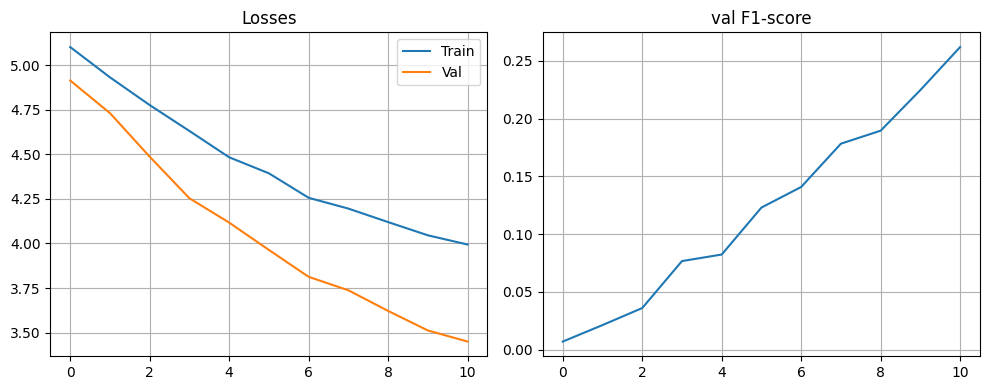

  6%|▌         | 12/200 [00:41<10:41,  3.41s/it]

!!! NEW BEST MODEL !!!
Epoch 11: train_loss 3.9499662169094742, val_loss 3.3653487058786244, val_f1 0.26441478531036133


  6%|▋         | 13/200 [00:44<10:37,  3.41s/it]

!!! NEW BEST MODEL !!!
Epoch 12: train_loss 3.8793000106153817, val_loss 3.2664714593153734, val_f1 0.31878590024938736


  7%|▋         | 14/200 [00:47<10:32,  3.40s/it]

!!! NEW BEST MODEL !!!
Epoch 13: train_loss 3.8294098377227783, val_loss 3.173256048789391, val_f1 0.32768761815853814


  8%|▊         | 15/200 [00:51<10:28,  3.40s/it]

!!! NEW BEST MODEL !!!
Epoch 14: train_loss 3.7590162918485444, val_loss 3.10285392174354, val_f1 0.3421254398946819


  8%|▊         | 16/200 [00:54<10:24,  3.39s/it]

!!! NEW BEST MODEL !!!
Epoch 15: train_loss 3.659696283011601, val_loss 3.0485300834362326, val_f1 0.3643033343556372


  8%|▊         | 17/200 [00:58<10:20,  3.39s/it]

!!! NEW BEST MODEL !!!
Epoch 16: train_loss 3.657490146571192, val_loss 2.990512334383451, val_f1 0.3756589527728384


  9%|▉         | 18/200 [01:01<10:16,  3.39s/it]

!!! NEW BEST MODEL !!!
Epoch 17: train_loss 3.6604921653352935, val_loss 2.9446251208965597, val_f1 0.39987417054526414


 10%|▉         | 19/200 [01:04<10:05,  3.35s/it]

Epoch 18: train_loss 3.5959811292845627, val_loss 2.898213808353131, val_f1 0.3906840299132437


 10%|█         | 20/200 [01:08<10:04,  3.36s/it]

!!! NEW BEST MODEL !!!
Epoch 19: train_loss 3.534306764602661, val_loss 2.8376732972952037, val_f1 0.411958904019344
Epoch 20: train_loss 3.5374452656713027, val_loss 2.8369752076955943, val_f1 0.4040653211691405


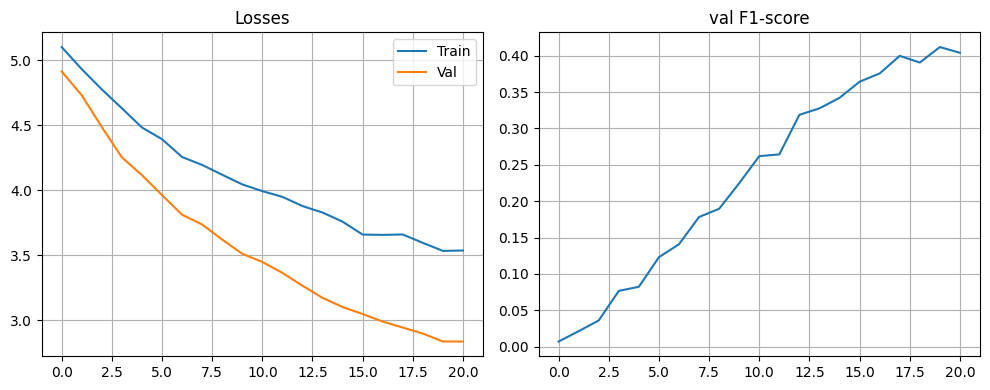

 11%|█         | 22/200 [01:14<09:58,  3.36s/it]

!!! NEW BEST MODEL !!!
Epoch 21: train_loss 3.4709408283233643, val_loss 2.791988886319674, val_f1 0.41656573630874144


 12%|█▏        | 23/200 [01:18<09:58,  3.38s/it]

!!! NEW BEST MODEL !!!
Epoch 22: train_loss 3.4340432676775703, val_loss 2.6973562974196215, val_f1 0.4363991531247298


 12%|█▏        | 24/200 [01:21<09:47,  3.34s/it]

Epoch 23: train_loss 3.393675343743686, val_loss 2.6567427011636586, val_f1 0.42718489724679815


 12%|█▎        | 25/200 [01:24<09:46,  3.35s/it]

!!! NEW BEST MODEL !!!
Epoch 24: train_loss 3.4105263414054083, val_loss 2.636593085068923, val_f1 0.4478952328407588


 13%|█▎        | 26/200 [01:28<09:45,  3.36s/it]

!!! NEW BEST MODEL !!!
Epoch 25: train_loss 3.380049105348258, val_loss 2.560329253856952, val_f1 0.45874798680841383


 14%|█▎        | 27/200 [01:31<09:43,  3.37s/it]

!!! NEW BEST MODEL !!!
Epoch 26: train_loss 3.316441461957734, val_loss 2.577540214245136, val_f1 0.4664688592952352


 14%|█▍        | 28/200 [01:35<09:40,  3.38s/it]

!!! NEW BEST MODEL !!!
Epoch 27: train_loss 3.2527969459007524, val_loss 2.5519852454845724, val_f1 0.47681388094062677


 14%|█▍        | 29/200 [01:38<09:30,  3.34s/it]

Epoch 28: train_loss 3.230503254923327, val_loss 2.5112354938800516, val_f1 0.4707073151325039


 15%|█▌        | 30/200 [01:41<09:21,  3.31s/it]

Epoch 29: train_loss 3.2169941129355597, val_loss 2.4707433993999777, val_f1 0.47066327807389985
!!! NEW BEST MODEL !!!
Epoch 30: train_loss 3.247272590111042, val_loss 2.430037333415105, val_f1 0.48812881093818383


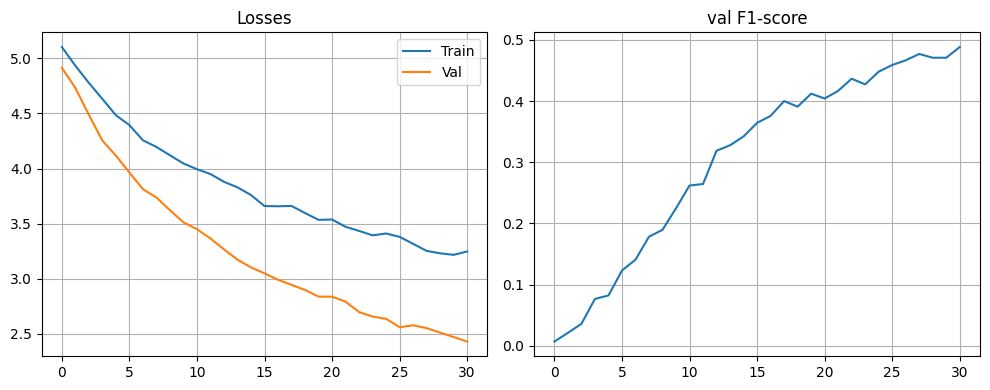

 16%|█▌        | 32/200 [01:48<09:18,  3.32s/it]

Epoch 31: train_loss 3.163001274240428, val_loss 2.397322122867291, val_f1 0.47238788395170106


 16%|█▋        | 33/200 [01:51<09:11,  3.30s/it]

Epoch 32: train_loss 3.08725617671835, val_loss 2.4161298274993896, val_f1 0.48808607430921164


 17%|█▋        | 34/200 [01:54<09:04,  3.28s/it]

Epoch 33: train_loss 3.156593865361707, val_loss 2.383460228259747, val_f1 0.47298406407846943


 18%|█▊        | 35/200 [01:58<08:59,  3.27s/it]

Epoch 34: train_loss 3.133722107985924, val_loss 2.3025233928973856, val_f1 0.487606093204292


 18%|█▊        | 36/200 [02:01<09:01,  3.30s/it]

!!! NEW BEST MODEL !!!
Epoch 35: train_loss 3.1275414105119377, val_loss 2.3659307956695557, val_f1 0.5067550444159529


 18%|█▊        | 37/200 [02:04<09:02,  3.33s/it]

!!! NEW BEST MODEL !!!
Epoch 36: train_loss 3.0668160093241723, val_loss 2.309761175742516, val_f1 0.5082185038036885


 19%|█▉        | 38/200 [02:08<09:01,  3.35s/it]

!!! NEW BEST MODEL !!!
Epoch 37: train_loss 3.045959316450974, val_loss 2.297940345910879, val_f1 0.5112697930988098


 20%|█▉        | 39/200 [02:11<08:54,  3.32s/it]

Epoch 38: train_loss 3.0421417581624, val_loss 2.2408386927384596, val_f1 0.5026162996208554


 20%|██        | 40/200 [02:14<08:47,  3.29s/it]

Epoch 39: train_loss 3.031889742818372, val_loss 2.2648156789632945, val_f1 0.5061302791202712
!!! NEW BEST MODEL !!!
Epoch 40: train_loss 2.9897828759818244, val_loss 2.2076751268827, val_f1 0.5173764168268946


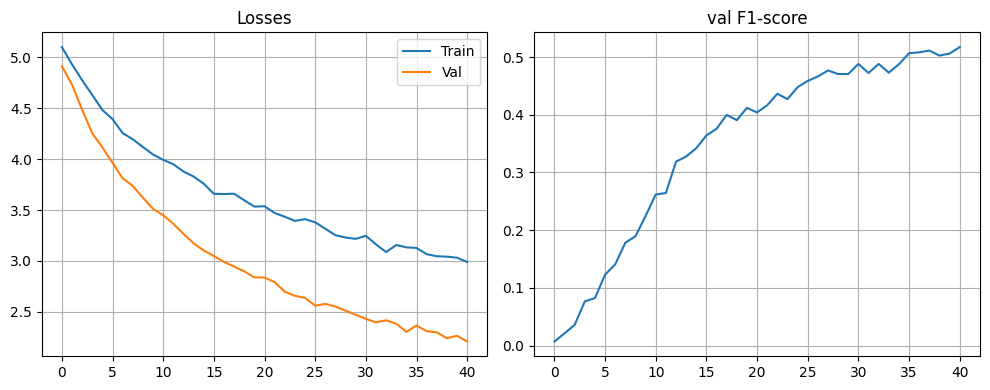

 21%|██        | 42/200 [02:21<08:46,  3.33s/it]

Epoch 41: train_loss 3.045855456385119, val_loss 2.195478604390071, val_f1 0.5149571542862307


 22%|██▏       | 43/200 [02:24<08:45,  3.35s/it]

!!! NEW BEST MODEL !!!
Epoch 42: train_loss 2.8903834326513884, val_loss 2.1647545099258423, val_f1 0.538860847347188


 22%|██▏       | 44/200 [02:28<08:38,  3.32s/it]

Epoch 43: train_loss 3.0015881061553955, val_loss 2.211145969537588, val_f1 0.5070984247013934


 22%|██▎       | 45/200 [02:31<08:31,  3.30s/it]

Epoch 44: train_loss 2.9843056777427934, val_loss 2.1790360670823317, val_f1 0.5292684767935282


 23%|██▎       | 46/200 [02:34<08:26,  3.29s/it]

Epoch 45: train_loss 2.970684232382939, val_loss 2.172427856005155, val_f1 0.5131346497858624


 24%|██▎       | 47/200 [02:37<08:21,  3.28s/it]

Epoch 46: train_loss 2.942668684597673, val_loss 2.0977007242349477, val_f1 0.5213067261648392


 24%|██▍       | 48/200 [02:41<08:17,  3.27s/it]

Epoch 47: train_loss 2.9716307623633025, val_loss 2.13363240315364, val_f1 0.5251290074516705


 24%|██▍       | 49/200 [02:44<08:18,  3.30s/it]

!!! NEW BEST MODEL !!!
Epoch 48: train_loss 2.890897981051741, val_loss 2.1470532967494083, val_f1 0.5419608887418363


 25%|██▌       | 50/200 [02:47<08:13,  3.29s/it]

Epoch 49: train_loss 2.86240685397181, val_loss 2.120532145866981, val_f1 0.5288029668108017
Epoch 50: train_loss 2.8975776228411445, val_loss 2.1060249713750987, val_f1 0.5352759723365897


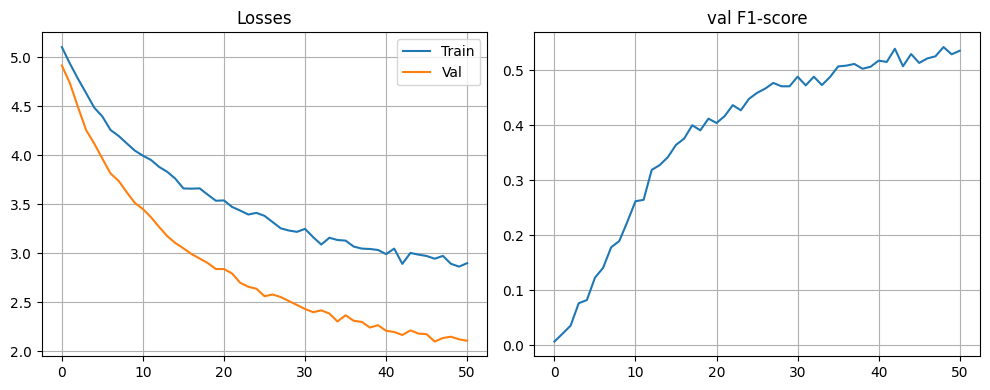

 26%|██▌       | 52/200 [02:54<08:06,  3.29s/it]

Epoch 51: train_loss 2.835226765994368, val_loss 2.109981509355398, val_f1 0.5245496110200335


 26%|██▋       | 53/200 [02:57<08:01,  3.27s/it]

Epoch 52: train_loss 2.838881410401443, val_loss 2.1352038291784434, val_f1 0.5121654865089772


 27%|██▋       | 54/200 [03:00<07:57,  3.27s/it]

Epoch 53: train_loss 2.844634146525942, val_loss 2.081910041662363, val_f1 0.5260819874493841


 28%|██▊       | 55/200 [03:04<07:52,  3.26s/it]

Epoch 54: train_loss 2.8792697232345055, val_loss 2.0628218284020057, val_f1 0.5246424172471116


 28%|██▊       | 56/200 [03:07<07:49,  3.26s/it]

Epoch 55: train_loss 2.7503867724846147, val_loss 2.0651198900662937, val_f1 0.5282720895861536


 28%|██▊       | 57/200 [03:10<07:45,  3.25s/it]

Epoch 56: train_loss 2.7467681457256448, val_loss 2.08819763477032, val_f1 0.524106894295642


 29%|██▉       | 58/200 [03:13<07:41,  3.25s/it]

Epoch 57: train_loss 2.8415749895161597, val_loss 2.0521873510800877, val_f1 0.5223994261084375


 30%|██▉       | 59/200 [03:17<07:38,  3.25s/it]

Epoch 58: train_loss 2.7991274800793877, val_loss 2.0537125789202175, val_f1 0.5351749008047769


 30%|███       | 60/200 [03:20<07:34,  3.25s/it]

Epoch 59: train_loss 2.6744571225396516, val_loss 2.040684755031879, val_f1 0.5380502266681442
Epoch 60: train_loss 2.782604159979985, val_loss 2.0397473115187426, val_f1 0.5279865283968571


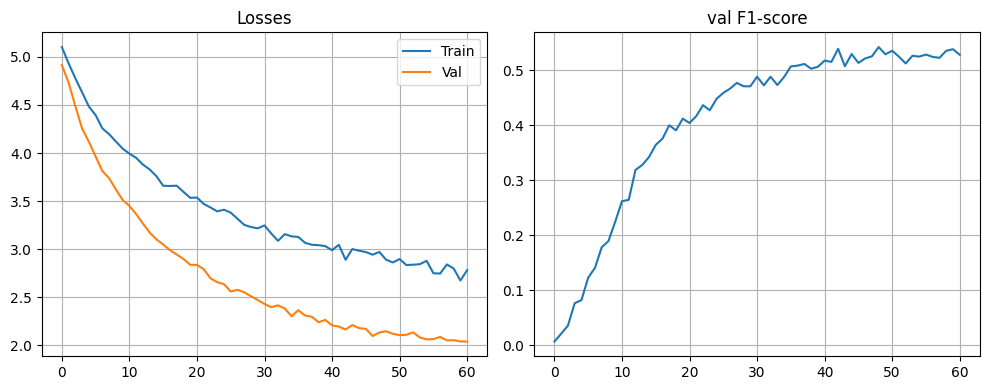

 31%|███       | 62/200 [03:26<07:30,  3.27s/it]

Epoch 61: train_loss 2.724268099357342, val_loss 2.0069367427092333, val_f1 0.5365149435778037


 32%|███▏      | 63/200 [03:30<07:26,  3.26s/it]

Epoch 62: train_loss 2.792410710762287, val_loss 2.0222878456115723, val_f1 0.5190397064433535


 32%|███▏      | 64/200 [03:33<07:22,  3.25s/it]

Epoch 63: train_loss 2.8419443656658303, val_loss 2.0031255942124586, val_f1 0.5271246141049611


 32%|███▎      | 65/200 [03:36<07:19,  3.25s/it]

Epoch 64: train_loss 2.7260126656499404, val_loss 2.0425889583734365, val_f1 0.5085211195637354


 33%|███▎      | 66/200 [03:39<07:15,  3.25s/it]

Epoch 65: train_loss 2.7359779867632636, val_loss 2.0353969427255483, val_f1 0.5381101906936268


 34%|███▎      | 67/200 [03:43<07:12,  3.25s/it]

Epoch 66: train_loss 2.75567207665279, val_loss 2.0294168362250695, val_f1 0.531153537669717


 34%|███▍      | 68/200 [03:46<07:09,  3.26s/it]

Epoch 67: train_loss 2.728587561640246, val_loss 1.995233260668241, val_f1 0.5368286798745086


 34%|███▍      | 69/200 [03:49<07:06,  3.25s/it]

Epoch 68: train_loss 2.7926900304597, val_loss 2.016640433898339, val_f1 0.5268501600317879


 35%|███▌      | 70/200 [03:53<07:07,  3.29s/it]

!!! NEW BEST MODEL !!!
Epoch 69: train_loss 2.75464443502755, val_loss 1.9870016758258526, val_f1 0.5435843699526999
Epoch 70: train_loss 2.678987404395794, val_loss 1.9800990911630483, val_f1 0.54105719614436


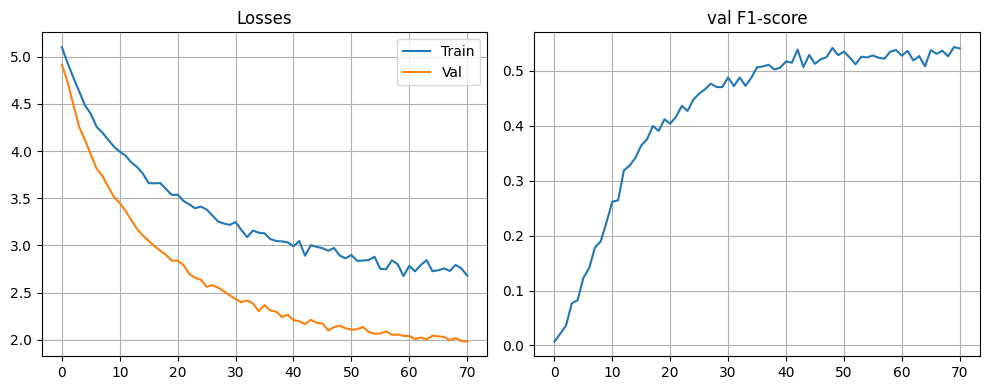

 36%|███▌      | 72/200 [03:59<07:03,  3.31s/it]

Epoch 71: train_loss 2.7516050585385026, val_loss 2.0063491876308737, val_f1 0.5195994413168469


 36%|███▋      | 73/200 [04:02<06:57,  3.29s/it]

Epoch 72: train_loss 2.788509956721602, val_loss 1.985579719910255, val_f1 0.528924047394575


 37%|███▋      | 74/200 [04:06<06:52,  3.27s/it]

Epoch 73: train_loss 2.751952154883023, val_loss 1.965991157751817, val_f1 0.5360043594761239


 38%|███▊      | 75/200 [04:09<06:48,  3.26s/it]

Epoch 74: train_loss 2.7471233483018547, val_loss 1.9566169426991389, val_f1 0.5354678695109615


 38%|███▊      | 76/200 [04:12<06:44,  3.26s/it]

Epoch 75: train_loss 2.7535117330222296, val_loss 1.9801819232793956, val_f1 0.5281169742542304


 38%|███▊      | 77/200 [04:15<06:40,  3.25s/it]

Epoch 76: train_loss 2.7259707368653396, val_loss 1.963334661263686, val_f1 0.5363300075181006


 39%|███▉      | 78/200 [04:19<06:36,  3.25s/it]

Epoch 77: train_loss 2.7320149684774466, val_loss 1.9641012870348418, val_f1 0.5332988889194007


 40%|███▉      | 79/200 [04:22<06:34,  3.26s/it]

Epoch 78: train_loss 2.6654903642062484, val_loss 1.957533442057096, val_f1 0.5378740939294052


 40%|████      | 80/200 [04:25<06:30,  3.26s/it]

Epoch 79: train_loss 2.665790853829219, val_loss 1.95579116161053, val_f1 0.5385001523804385
!!! NEW BEST MODEL !!!
Epoch 80: train_loss 2.7319285047465356, val_loss 1.9656937489142785, val_f1 0.5477517720736287


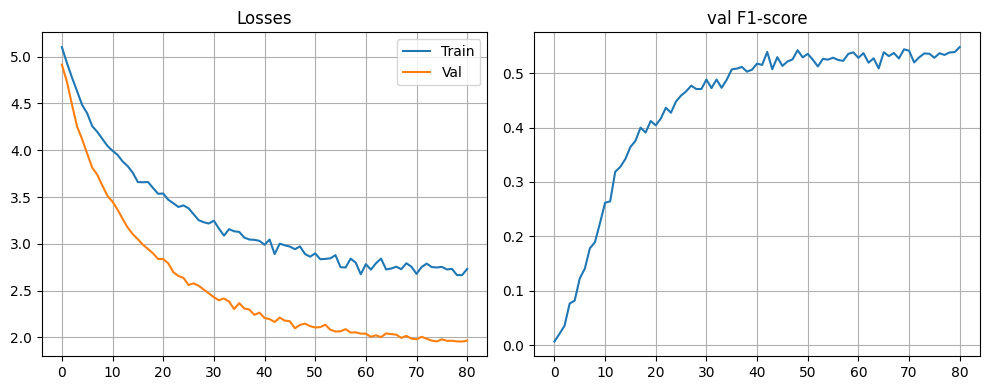

 41%|████      | 82/200 [04:32<06:30,  3.31s/it]

Epoch 81: train_loss 2.7509506159815293, val_loss 1.9682266803888173, val_f1 0.5418028908038608


 42%|████▏     | 83/200 [04:35<06:30,  3.34s/it]

!!! NEW BEST MODEL !!!
Epoch 82: train_loss 2.668079639303273, val_loss 1.9352638171269343, val_f1 0.5481534271423607


 42%|████▏     | 84/200 [04:39<06:24,  3.32s/it]

Epoch 83: train_loss 2.6383523612186828, val_loss 1.9802225919870229, val_f1 0.5339729597143886


 42%|████▎     | 85/200 [04:42<06:19,  3.30s/it]

Epoch 84: train_loss 2.7099448401352455, val_loss 1.9563193229528575, val_f1 0.5425074492996277


 43%|████▎     | 86/200 [04:45<06:13,  3.28s/it]

Epoch 85: train_loss 2.572705104433257, val_loss 1.9650374834354107, val_f1 0.5338218627335052


 44%|████▎     | 87/200 [04:48<06:09,  3.27s/it]

Epoch 86: train_loss 2.665414867729976, val_loss 1.9640402793884277, val_f1 0.5257284427446943


 44%|████▍     | 88/200 [04:52<06:06,  3.27s/it]

Epoch 87: train_loss 2.697056975857965, val_loss 1.9865874143747182, val_f1 0.5399520613358008


 44%|████▍     | 89/200 [04:55<06:02,  3.27s/it]

Epoch 88: train_loss 2.7022890551336882, val_loss 1.970017671585083, val_f1 0.5344814390121433


 45%|████▌     | 90/200 [04:58<05:58,  3.26s/it]

Epoch 89: train_loss 2.6692044981594742, val_loss 1.9642993028347309, val_f1 0.5321155249899986


In [ ]:
model = ic(PockemonModel(
    img_shape=IN_SHAPE,
    in_ch=3,
    hidden_ch=[32, 64, 128],
    hidden_fc=[512, 256],
    out_dim=150
))

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

train_loop(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    model_name="best_model_003.pth",
    num_epoches=200
)


ic| PockemonModel(
        img_shape=(224, 224),
        in_ch=3,
        hidden_ch=[32, 64, 128],
        hidden_fc=[512, 256, 128],
        out_dim=150
    ): PockemonModel(
         (conv_net): Sequential(
           (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (2): ReLU()
           (3): Dropout2d(p=0.2, inplace=False)
           (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (6): ReLU()
           (7): Dropout2d(p=0.2, inplace=False)
           (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
           (9): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (11): ReLU()


!!! NEW BEST MODEL !!!
Epoch 0: train_loss 3.9703298848250816, val_loss 3.1315746307373047, val_f1 0.3504772799196992


  2%|▏         | 2/100 [00:19<16:16,  9.96s/it]

!!! NEW BEST MODEL !!!
Epoch 1: train_loss 3.9341724987687736, val_loss 3.0097398391136756, val_f1 0.3831130633180072


  3%|▎         | 3/100 [00:29<15:38,  9.67s/it]

Epoch 2: train_loss 3.924712896347046, val_loss 3.066094306799082, val_f1 0.3580032045518803


  4%|▍         | 4/100 [00:38<15:14,  9.52s/it]

Epoch 3: train_loss 3.9668272774795006, val_loss 3.0006670401646542, val_f1 0.37364762612654884


  5%|▌         | 5/100 [00:47<14:59,  9.47s/it]

Epoch 4: train_loss 3.8746195743823875, val_loss 3.0285169161283054, val_f1 0.37225012208706465


  6%|▌         | 6/100 [00:57<14:46,  9.43s/it]

Epoch 5: train_loss 3.916839887355936, val_loss 3.0028064984541674, val_f1 0.3631083440277502


  7%|▋         | 7/100 [01:06<14:33,  9.39s/it]

Epoch 6: train_loss 3.8958958592908135, val_loss 3.0148312678703895, val_f1 0.3663578249706772


  8%|▊         | 8/100 [01:15<14:21,  9.37s/it]

Epoch 7: train_loss 3.921483138511921, val_loss 2.9944451588850756, val_f1 0.36820065153850834


  9%|▉         | 9/100 [01:25<14:10,  9.35s/it]

Epoch 8: train_loss 3.9223394558347504, val_loss 2.9648285462306094, val_f1 0.3504887354501682


 10%|█         | 10/100 [01:35<14:13,  9.48s/it]

!!! NEW BEST MODEL !!!
Epoch 9: train_loss 3.9082297621102167, val_loss 2.9689036332643948, val_f1 0.38697377500298635
Epoch 10: train_loss 3.9259756844619225, val_loss 2.9530458450317383, val_f1 0.3868727349270073


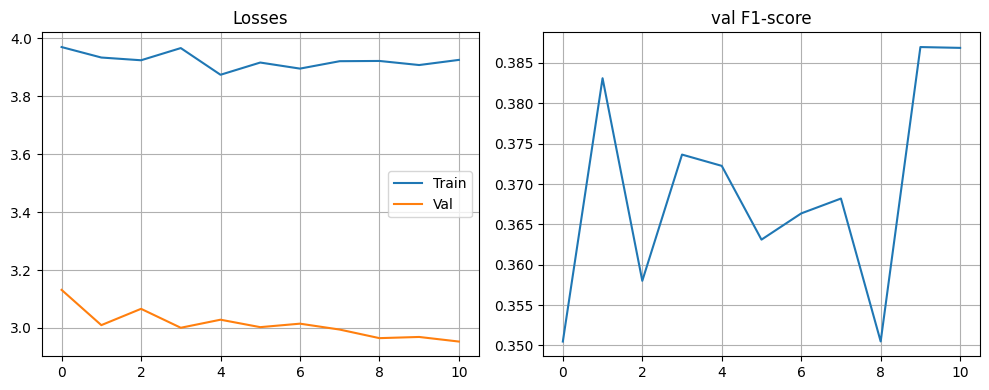

 12%|█▏        | 12/100 [01:53<13:49,  9.43s/it]

Epoch 11: train_loss 3.838655874646943, val_loss 2.9849249766423154, val_f1 0.37768001606985774


 13%|█▎        | 13/100 [02:03<13:50,  9.54s/it]

!!! NEW BEST MODEL !!!
Epoch 12: train_loss 3.9453544452272613, val_loss 2.9200599927168627, val_f1 0.3933657589330676


 14%|█▍        | 14/100 [02:13<13:47,  9.62s/it]

!!! NEW BEST MODEL !!!
Epoch 13: train_loss 3.813959236802726, val_loss 2.9282954105964074, val_f1 0.40035187178648457


 15%|█▌        | 15/100 [02:22<13:29,  9.53s/it]

Epoch 14: train_loss 3.83369491018098, val_loss 2.9597336879143348, val_f1 0.39134671651356256


 16%|█▌        | 16/100 [02:32<13:27,  9.61s/it]

!!! NEW BEST MODEL !!!
Epoch 15: train_loss 3.843402418596991, val_loss 2.94523470218365, val_f1 0.4015154434745304


 17%|█▋        | 17/100 [02:41<13:10,  9.52s/it]

Epoch 16: train_loss 3.900128487882943, val_loss 2.9590570009671726, val_f1 0.36972944444975614


 18%|█▊        | 18/100 [02:51<12:55,  9.46s/it]

Epoch 17: train_loss 3.8477171700576256, val_loss 2.9398118349222035, val_f1 0.3870504839532828


 19%|█▉        | 19/100 [03:00<12:42,  9.41s/it]

Epoch 18: train_loss 3.8690975945571373, val_loss 2.9168533912071815, val_f1 0.3903157857378934


 20%|██        | 20/100 [03:10<12:41,  9.52s/it]

!!! NEW BEST MODEL !!!
Epoch 19: train_loss 3.838724498091073, val_loss 2.9202960454500637, val_f1 0.40182082082395526
Epoch 20: train_loss 3.794866241257766, val_loss 3.013143099271334, val_f1 0.36287393529250894


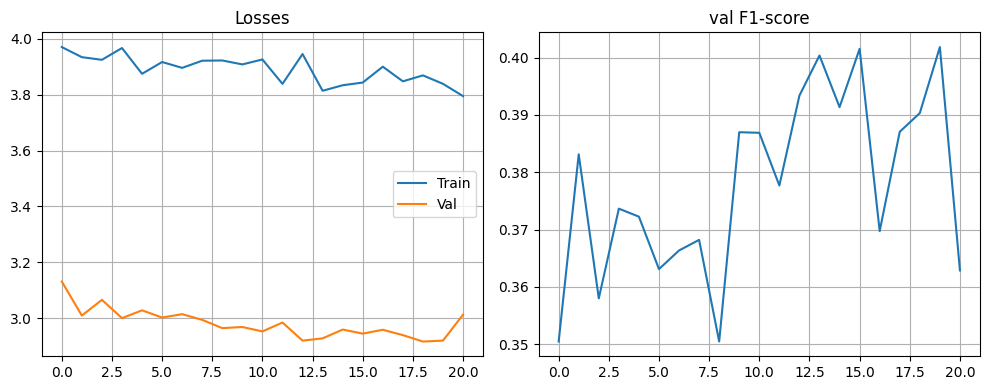

 22%|██▏       | 22/100 [03:29<12:16,  9.44s/it]

Epoch 21: train_loss 3.8683951969804435, val_loss 2.898098743878878, val_f1 0.39937882241455963


 23%|██▎       | 23/100 [03:38<12:14,  9.54s/it]

!!! NEW BEST MODEL !!!
Epoch 22: train_loss 3.7648590515399802, val_loss 2.884911977327787, val_f1 0.4157447339919882


 24%|██▍       | 24/100 [03:48<12:00,  9.47s/it]

Epoch 23: train_loss 3.748108074582856, val_loss 2.9477069561298075, val_f1 0.3713028262404695


 25%|██▌       | 25/100 [03:57<11:46,  9.42s/it]

Epoch 24: train_loss 3.803044919309945, val_loss 2.91093582373399, val_f1 0.4013347160773572


 26%|██▌       | 26/100 [04:06<11:34,  9.39s/it]

Epoch 25: train_loss 3.8418277460953285, val_loss 2.862787760221041, val_f1 0.38815002543982413


 27%|██▋       | 27/100 [04:16<11:24,  9.38s/it]

Epoch 26: train_loss 3.8340658319407495, val_loss 2.8733730499561014, val_f1 0.3935482441304898


 28%|██▊       | 28/100 [04:25<11:13,  9.36s/it]

Epoch 27: train_loss 3.778356437025399, val_loss 2.8976568625523496, val_f1 0.3971210432520535


 29%|██▉       | 29/100 [04:34<11:03,  9.34s/it]

Epoch 28: train_loss 3.8072146793891646, val_loss 2.897382534467257, val_f1 0.3965102360376325


 30%|███       | 30/100 [04:43<10:53,  9.33s/it]

Epoch 29: train_loss 3.8222778254541856, val_loss 2.8878842133742113, val_f1 0.4035944355487509
Epoch 30: train_loss 3.8108884301678887, val_loss 2.8812610736260047, val_f1 0.39066678192167276


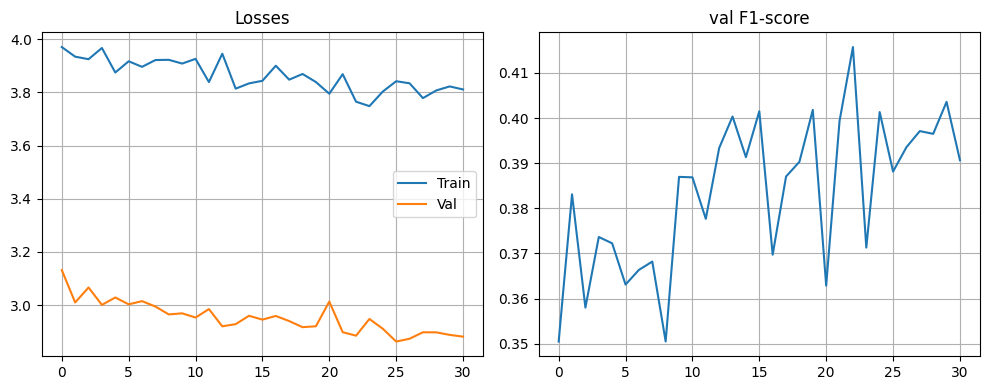

 32%|███▏      | 32/100 [05:02<10:35,  9.35s/it]

Epoch 31: train_loss 3.79164692451214, val_loss 2.8661193480858436, val_f1 0.4022562061925258


 33%|███▎      | 33/100 [05:12<10:25,  9.34s/it]

Epoch 32: train_loss 3.7680840492248535, val_loss 2.8016022168673, val_f1 0.4143750330595266


 34%|███▍      | 34/100 [05:21<10:25,  9.48s/it]

!!! NEW BEST MODEL !!!
Epoch 33: train_loss 3.783039290329506, val_loss 2.787371378678542, val_f1 0.41720168492481374


 35%|███▌      | 35/100 [05:31<10:12,  9.43s/it]

Epoch 34: train_loss 3.7671981926622062, val_loss 2.848487909023578, val_f1 0.41076675991173534


 36%|███▌      | 36/100 [05:40<10:01,  9.40s/it]

Epoch 35: train_loss 3.713793524380388, val_loss 2.804488072028527, val_f1 0.41270850968263173


 37%|███▋      | 37/100 [05:49<09:51,  9.38s/it]

Epoch 36: train_loss 3.7185198027512123, val_loss 2.8630385949061465, val_f1 0.3907681380756577


 38%|███▊      | 38/100 [05:59<09:40,  9.36s/it]

Epoch 37: train_loss 3.727400886601415, val_loss 2.801033588556143, val_f1 0.41012965697660814


 39%|███▉      | 39/100 [06:08<09:30,  9.36s/it]

Epoch 38: train_loss 3.7657434364845015, val_loss 2.8104305817530704, val_f1 0.40820253389400446


 40%|████      | 40/100 [06:17<09:20,  9.35s/it]

Epoch 39: train_loss 3.7455404955765297, val_loss 2.8070600766402025, val_f1 0.40351376292666846
Epoch 40: train_loss 3.7784387818698226, val_loss 2.7668928916637716, val_f1 0.41194424391351686


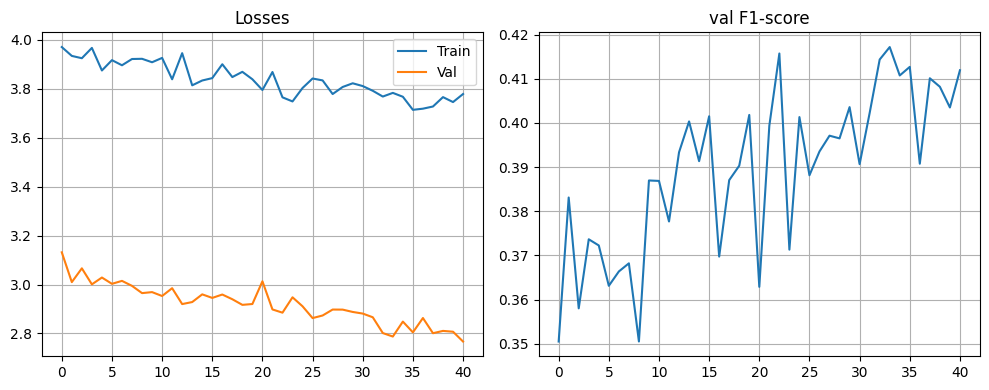

 42%|████▏     | 42/100 [06:36<09:03,  9.36s/it]

Epoch 41: train_loss 3.763290923217247, val_loss 2.776689786177415, val_f1 0.39751923556934327


 43%|████▎     | 43/100 [06:45<08:53,  9.35s/it]

Epoch 42: train_loss 3.737655623205777, val_loss 2.8416007298689623, val_f1 0.39266887278558793


 44%|████▍     | 44/100 [06:55<08:43,  9.34s/it]

Epoch 43: train_loss 3.6927325561128814, val_loss 2.7861216251666727, val_f1 0.39684130132737977


 45%|████▌     | 45/100 [07:04<08:33,  9.33s/it]

Epoch 44: train_loss 3.681169559215677, val_loss 2.824477800956139, val_f1 0.4059416439168717


 46%|████▌     | 46/100 [07:13<08:23,  9.33s/it]

Epoch 45: train_loss 3.7553520449276627, val_loss 2.798996851994441, val_f1 0.3886352207044718


 47%|████▋     | 47/100 [07:23<08:14,  9.32s/it]

Epoch 46: train_loss 3.645393124942122, val_loss 2.8205836369441104, val_f1 0.40751512636594794


 48%|████▊     | 48/100 [07:32<08:12,  9.46s/it]

!!! NEW BEST MODEL !!!
Epoch 47: train_loss 3.7342982374388596, val_loss 2.750761087124164, val_f1 0.4213817409652221


 49%|████▉     | 49/100 [07:42<08:00,  9.42s/it]

Epoch 48: train_loss 3.710453074553917, val_loss 2.7718250934894266, val_f1 0.4066103946359482


 50%|█████     | 50/100 [07:51<07:49,  9.39s/it]

Epoch 49: train_loss 3.721901589426501, val_loss 2.754722466835609, val_f1 0.4143374691985288
!!! NEW BEST MODEL !!!
Epoch 50: train_loss 3.7806997052554427, val_loss 2.7788795141073375, val_f1 0.4303476559356656


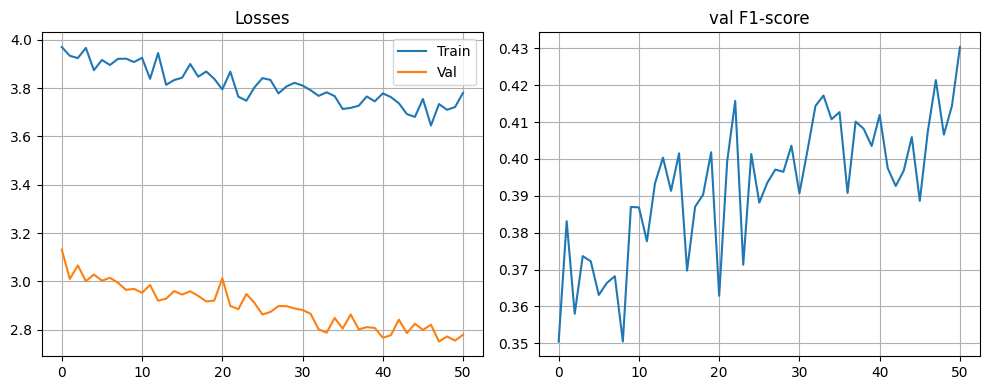

 52%|█████▏    | 52/100 [08:10<07:34,  9.46s/it]

Epoch 51: train_loss 3.765047369332149, val_loss 2.677871300623967, val_f1 0.43031826641288345


 53%|█████▎    | 53/100 [08:20<07:22,  9.40s/it]

Epoch 52: train_loss 3.723807195137287, val_loss 2.7751844112689676, val_f1 0.4083220050111763


 54%|█████▍    | 54/100 [08:29<07:11,  9.39s/it]

Epoch 53: train_loss 3.638182853830272, val_loss 2.7875608114095836, val_f1 0.4302032878786332


 55%|█████▌    | 55/100 [08:38<07:01,  9.37s/it]

Epoch 54: train_loss 3.676317576704354, val_loss 2.7913368298457217, val_f1 0.41561656285640597


 56%|█████▌    | 56/100 [08:48<06:51,  9.35s/it]

Epoch 55: train_loss 3.677205126861046, val_loss 2.730420479407677, val_f1 0.412453477969684


 57%|█████▋    | 57/100 [08:57<06:41,  9.35s/it]

Epoch 56: train_loss 3.702420029146918, val_loss 2.7304500066317043, val_f1 0.42030639256524205


 58%|█████▊    | 58/100 [09:06<06:32,  9.34s/it]

Epoch 57: train_loss 3.642029112782972, val_loss 2.7182775827554555, val_f1 0.40452878361250394


 59%|█████▉    | 59/100 [09:16<06:28,  9.48s/it]

!!! NEW BEST MODEL !!!
Epoch 58: train_loss 3.687546869804119, val_loss 2.7360790142646203, val_f1 0.4362708486571271


 60%|██████    | 60/100 [09:25<06:17,  9.43s/it]

Epoch 59: train_loss 3.6960177750423036, val_loss 2.736134639153114, val_f1 0.4238285726386037
Epoch 60: train_loss 3.7076488198905158, val_loss 2.721717045857356, val_f1 0.41368691171633076


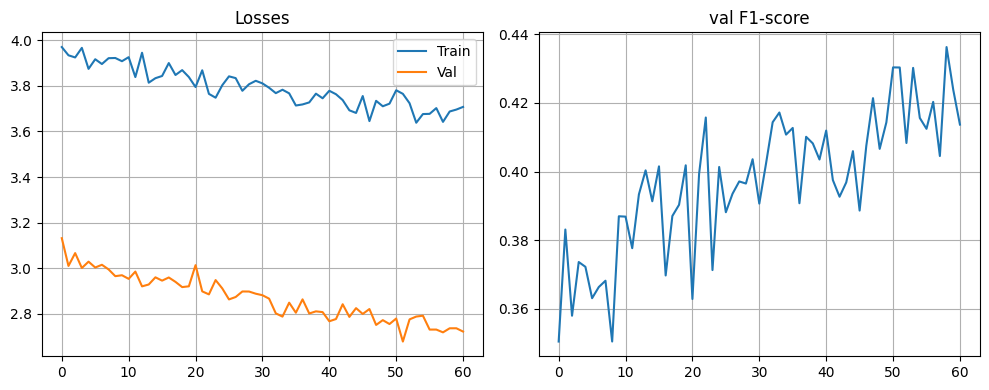

 62%|██████▏   | 62/100 [09:44<05:57,  9.39s/it]

Epoch 61: train_loss 3.683055335077746, val_loss 2.699922745044415, val_f1 0.4320084533795807


 63%|██████▎   | 63/100 [09:53<05:46,  9.37s/it]

Epoch 62: train_loss 3.6766197845853608, val_loss 2.7557628521552453, val_f1 0.4139100710523018


 64%|██████▍   | 64/100 [10:03<05:36,  9.35s/it]

Epoch 63: train_loss 3.635288189197409, val_loss 2.713045597076416, val_f1 0.4151350349238899


 65%|██████▌   | 65/100 [10:12<05:26,  9.34s/it]

Epoch 64: train_loss 3.7012441076081375, val_loss 2.7158826864682712, val_f1 0.4081050241170393


 66%|██████▌   | 66/100 [10:21<05:17,  9.33s/it]

Epoch 65: train_loss 3.6285109273318588, val_loss 2.6906898205096903, val_f1 0.43285174084155953


 67%|██████▋   | 67/100 [10:31<05:07,  9.33s/it]

Epoch 66: train_loss 3.619809052039837, val_loss 2.7300470425532413, val_f1 0.41526931086798374


 68%|██████▊   | 68/100 [10:40<04:58,  9.32s/it]

Epoch 67: train_loss 3.654015467084687, val_loss 2.769727578529945, val_f1 0.39789570888321674


 69%|██████▉   | 69/100 [10:49<04:48,  9.32s/it]

Epoch 68: train_loss 3.6519190031906654, val_loss 2.7315876483917236, val_f1 0.4245815506357066


 70%|███████   | 70/100 [10:59<04:39,  9.32s/it]

Epoch 69: train_loss 3.7116643806983687, val_loss 2.6759610909682054, val_f1 0.40609165872141406
Epoch 70: train_loss 3.648653145494132, val_loss 2.678977214373075, val_f1 0.408182917003499


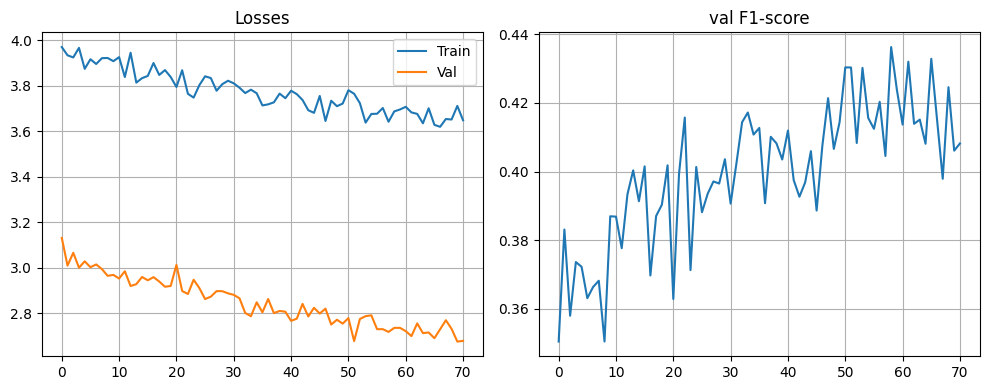

 72%|███████▏  | 72/100 [11:17<04:21,  9.35s/it]

Epoch 71: train_loss 3.6247376655710153, val_loss 2.704408884048462, val_f1 0.4214552768159845


 73%|███████▎  | 73/100 [11:27<04:12,  9.34s/it]

Epoch 72: train_loss 3.6767069964573302, val_loss 2.7177026455218973, val_f1 0.4154686644400323


 74%|███████▍  | 74/100 [11:36<04:02,  9.33s/it]

Epoch 73: train_loss 3.647036807290439, val_loss 2.674061206670908, val_f1 0.4213813914866728


 75%|███████▌  | 75/100 [11:45<03:53,  9.32s/it]

Epoch 74: train_loss 3.6125850759703537, val_loss 2.6959009170532227, val_f1 0.4204064214252444


 76%|███████▌  | 76/100 [11:55<03:43,  9.32s/it]

Epoch 75: train_loss 3.644300543028733, val_loss 2.6824481120476356, val_f1 0.41417344997064465


 77%|███████▋  | 77/100 [12:04<03:34,  9.32s/it]

Epoch 76: train_loss 3.6549618573024354, val_loss 2.684794077506432, val_f1 0.41198536512330347


 78%|███████▊  | 78/100 [12:13<03:24,  9.31s/it]

Epoch 77: train_loss 3.6266782201569656, val_loss 2.6727682993962216, val_f1 0.41088632533256125


 79%|███████▉  | 79/100 [12:22<03:15,  9.31s/it]

Epoch 78: train_loss 3.606120997461779, val_loss 2.742709233210637, val_f1 0.4213267763310791


 80%|████████  | 80/100 [12:32<03:06,  9.31s/it]

Epoch 79: train_loss 3.6085707154767266, val_loss 2.6615106692680945, val_f1 0.41121461041177826
Epoch 80: train_loss 3.6058670159043937, val_loss 2.694896019422091, val_f1 0.4182426079833107


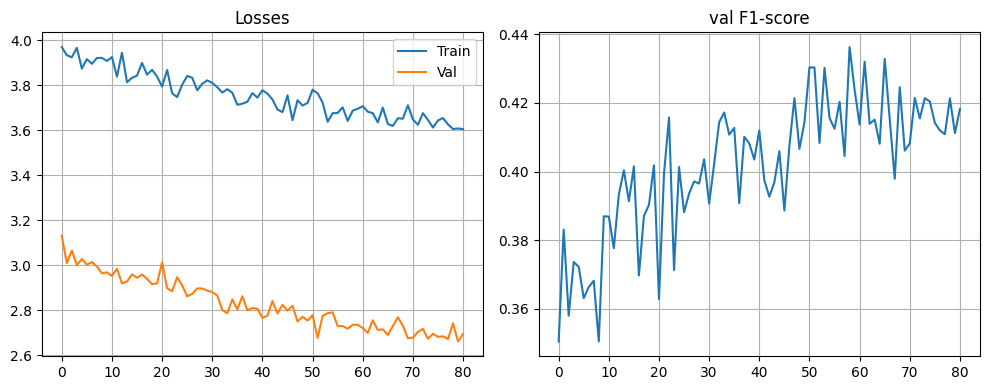

 82%|████████▏ | 82/100 [12:50<02:47,  9.33s/it]

Epoch 81: train_loss 3.5456321568324647, val_loss 2.730217511837299, val_f1 0.41891394094810275


 83%|████████▎ | 83/100 [13:00<02:38,  9.32s/it]

Epoch 82: train_loss 3.5996302654003274, val_loss 2.761221353824322, val_f1 0.4116486142680541


 84%|████████▍ | 84/100 [13:09<02:29,  9.33s/it]

Epoch 83: train_loss 3.5513376531929803, val_loss 2.6869442829718957, val_f1 0.41952213697224644


 85%|████████▌ | 85/100 [13:18<02:19,  9.32s/it]

Epoch 84: train_loss 3.613649006547599, val_loss 2.670914356525128, val_f1 0.4122484324421117


 86%|████████▌ | 86/100 [13:28<02:10,  9.32s/it]

Epoch 85: train_loss 3.522255642660733, val_loss 2.725590540812566, val_f1 0.41251812254334763


 87%|████████▋ | 87/100 [13:37<02:01,  9.33s/it]

Epoch 86: train_loss 3.5881279172568488, val_loss 2.654925749852107, val_f1 0.4193594598040798


 88%|████████▊ | 88/100 [13:46<01:51,  9.33s/it]

Epoch 87: train_loss 3.631258257504167, val_loss 2.6766627568465013, val_f1 0.4118480224566996


 89%|████████▉ | 89/100 [13:56<01:42,  9.31s/it]

Epoch 88: train_loss 3.5958738327026367, val_loss 2.6873749586252065, val_f1 0.4116732651791658


 90%|█████████ | 90/100 [14:05<01:33,  9.31s/it]

Epoch 89: train_loss 3.5881635649450896, val_loss 2.6727761855492225, val_f1 0.41649592593586215
Epoch 90: train_loss 3.5765058007733574, val_loss 2.6990414949563832, val_f1 0.41791457835131685


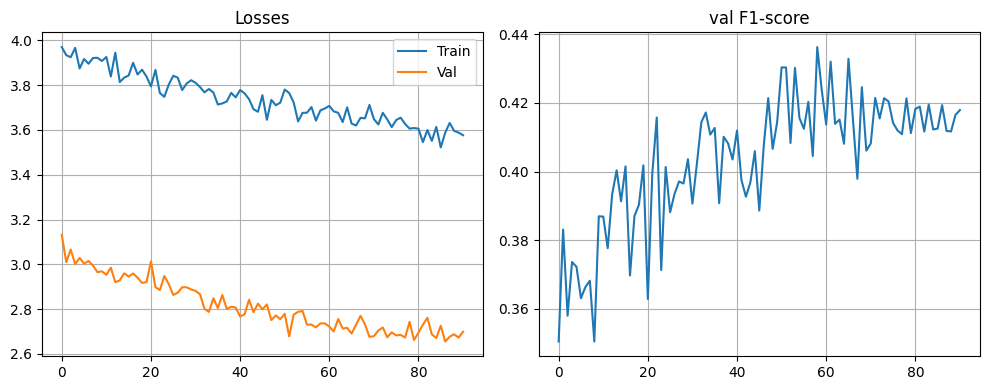

 92%|█████████▏| 92/100 [14:24<01:14,  9.33s/it]

Epoch 91: train_loss 3.651380785580339, val_loss 2.660900299365704, val_f1 0.4201821290838808


 93%|█████████▎| 93/100 [14:33<01:05,  9.33s/it]

Epoch 92: train_loss 3.6238530422079154, val_loss 2.6231636084043064, val_f1 0.4260406833787207


 94%|█████████▍| 94/100 [14:42<00:55,  9.32s/it]

Epoch 93: train_loss 3.592406823717315, val_loss 2.65547880759606, val_f1 0.409088167728191


 95%|█████████▌| 95/100 [14:52<00:47,  9.47s/it]

!!! NEW BEST MODEL !!!
Epoch 94: train_loss 3.567229484689647, val_loss 2.638559964986948, val_f1 0.4408856289821139


 96%|█████████▌| 96/100 [15:01<00:37,  9.43s/it]

Epoch 95: train_loss 3.5751450719504523, val_loss 2.634198408860427, val_f1 0.4241656257197796


 97%|█████████▋| 97/100 [15:11<00:28,  9.53s/it]

!!! NEW BEST MODEL !!!
Epoch 96: train_loss 3.5684118106447418, val_loss 2.5997054760272684, val_f1 0.4459493811030855


 98%|█████████▊| 98/100 [15:21<00:18,  9.47s/it]

Epoch 97: train_loss 3.5085472978394607, val_loss 2.6464482087355394, val_f1 0.44515726560492075


 99%|█████████▉| 99/100 [15:30<00:09,  9.43s/it]

Epoch 98: train_loss 3.549638402873072, val_loss 2.642648458480835, val_f1 0.4421856134805543
Epoch 99: train_loss 3.5749449154426314, val_loss 2.5838612593137302, val_f1 0.42414684863925295


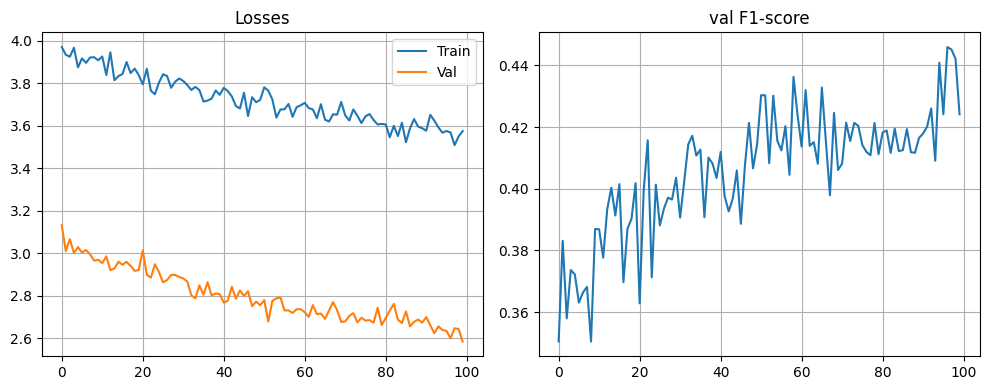

100%|██████████| 100/100 [15:39<00:00,  9.40s/it]

Best score: 0.4459493811030855


PockemonModel(
  (conv_net): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.2, inplace=False)
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout2d(p=0.2, inplace=False)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Dropout2d(p=0.2, inplace=False)
    (13): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): ReLU()
    (16): Dropout2d(p=0.2, 

In [ ]:
# model = ic(PockemonModel(
#     img_shape=(224, 224),
#     in_ch=3,
#     hidden_ch=[32, 64, 128],
#     hidden_fc=[512, 256, 128],
#     out_dim=150
# ))

# model.load_state_dict(torch.load('./models/best_model_001.pth'))

# optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
# criterion = nn.CrossEntropyLoss()

# train_loop(
#     model=model,
#     train_loader=train_dataloader,
#     val_loader=val_dataloader,
#     optimizer=optimizer,
#     criterion=criterion,
#     model_name="best_model_002.pth"
# )


## Inference

In [ ]:
model = ic(PockemonModel(
    img_shape=(224, 224),
    in_ch=3,
    hidden_ch=[32, 64, 128],
    hidden_fc=[512, 256, 128],
    out_dim=150
))
model.load_state_dict(torch.load('./models/best_model_002.pth'))

ic| PockemonModel(
        img_shape=(224, 224),
        in_ch=3,
        hidden_ch=[32, 64, 128],
        hidden_fc=[512, 256, 128],
        out_dim=150
    ): PockemonModel(
         (conv_net): Sequential(
           (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (2): ReLU()
           (3): Dropout2d(p=0.2, inplace=False)
           (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (6): ReLU()
           (7): Dropout2d(p=0.2, inplace=False)
           (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
           (9): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (11): ReLU()


<All keys matched successfully>

In [ ]:
df_ss = pd.read_csv("./data/sample_submission.csv")
df_ss.head()

,id,label
0,9553b359,Pikachu
1,c6bcf2c2,Pikachu
2,5493d25f,Pikachu
3,f17f13b5,Pikachu
4,bb4e5386,Pikachu


In [ ]:
test_dataset[0]

(tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.0837, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.0837, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.0837, -2.1179, -2.1179],
          ...,
          [-2.1179, -2.1179, -2.1008,  ..., -1.4672, -1.4672, -2.1179],
          [-2.1179, -2.1179, -2.1008,  ..., -1.4500, -1.4158, -2.1179],
          [-2.1179, -2.1179, -2.0837,  ..., -1.3644, -1.3644, -2.1179]],
 
         [[-2.0357, -2.0357, -2.0357,  ..., -1.9657, -2.0007, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -1.9657, -2.0007, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -1.9657, -2.0007, -2.0357],
          ...,
          [-2.0357, -2.0007, -1.9307,  ..., -0.6877, -0.7752, -1.9307],
          [-2.0182, -1.9832, -1.9482,  ..., -0.6702, -0.7227, -1.9482],
          [-2.0182, -1.9832, -1.9307,  ..., -0.5826, -0.6702, -1.9482]],
 
         [[-1.8044, -1.8044, -1.8044,  ..., -1.5256, -1.5604, -1.6127],
          [-1.8044, -1.8044,

In [ ]:
pred_dict = dict()

model.eval()
with torch.no_grad():
    for i in trange(len(test_dataset)):
        X, y = test_dataset[i]
        X = X.unsqueeze(0)
        id = test_dataset.df.iloc[i]['id']
        pred = model(X).argmax().numpy()
        pred_dict[id] = label_encoder.inverse_transform([pred])[0]

100%|██████████| 1748/1748 [00:28<00:00, 60.63it/s]


{'9553b359': 'Arbok',
 'c6bcf2c2': 'Mankey',
 '5493d25f': 'Fearow',
 'f17f13b5': 'Vaporeon',
 'bb4e5386': 'Jolteon',
 'eb70561f': 'Ivysaur',
 '29e8914c': 'Golduck',
 'fb758c76': 'Nidoking',
 'aa4cc0be': 'Tangela',
 'c91bf142': 'Tentacool',
 '51df204f': 'Poliwag',
 'c192e529': 'Dratini',
 '2c0990e7': 'Magnemite',
 '822aba76': 'Wigglytuff',
 '3be0da63': 'Pidgeot',
 '61899759': 'Nidoking',
 '21f7251f': 'Machoke',
 '14637932': 'Arcanine',
 'aa4894ae': 'Raichu',
 'b689bdcf': 'Wigglytuff',
 'dc906841': 'Ivysaur',
 'd3f0047b': 'Alakazam',
 'f3805681': 'Golduck',
 '05b51fbf': 'Cubone',
 'ac9aa0ba': 'Diglett',
 '7bc21c4d': 'Mewtwo',
 '8713f6de': 'Magnemite',
 '1339ee2a': 'Flareon',
 '29410709': 'Exeggcute',
 '53db180d': 'Poliwrath',
 '416f85e6': 'Staryu',
 '296b993e': 'Machamp',
 '6aa077f0': 'Kingler',
 '96997e40': 'Snorlax',
 'd536f5b7': 'Clefairy',
 '3bdfd063': 'Lapras',
 '88fe7416': 'Marowak',
 'a4868ece': 'Gyarados',
 'ad6a42fe': 'Dratini',
 'dc731aca': 'Horsea',
 '1e7f2e0c': 'Charmeleon',


In [ ]:
df_ss['label'] = df_ss['id'].map(pred_dict)
df_ss.to_csv("./subm.csv", index=False)
df_ss.head()

,id,label
0,9553b359,Arbok
1,c6bcf2c2,Mankey
2,5493d25f,Fearow
3,f17f13b5,Vaporeon
4,bb4e5386,Jolteon
